In [4]:
#@title Exercice 4.1

def factoriel(n):
    if n == 0 or n == 1:
        return 1
    else:
        return n * factoriel(n-1)

print(factoriel(6))

720


In [3]:
#@title Exercice 4.2

def applatir_listes_recursif(liste_listes, liste_fusionnee):
    for element in liste_listes:
        if type(element) is list:
            applatir_listes_recursif(element, liste_fusionnee)
        else:
            liste_fusionnee.append(element)

def applatir_listes(liste_listes):
    liste_fusionnee = []
    applatir_listes_recursif(liste_listes, liste_fusionnee)
    return liste_fusionnee

la_liste = [1,2,[3,4],[[5, 6],[[7,8],[9,10]]],11,[12,13],[14,15,[16,[17]],18,[[ ]],19,[ ]], 20]

print(applatir_listes(la_liste))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [2]:
#@title Exercice 4.3


def recherche_dichotomique(elements, cible):
    # Méthode récursive pour la recherche dichotomique
    # Elle est seulement visible à l'intérieur de la fonction recherche_dichotomique
    # C'est une technique de base sur la récursivité : on définit une fonction à l'intérieur d'une autre fonction
    # Quand le langage le permet, cela permet de cacher la fonction récursive à l'extérieur de la fonction principale.
    def recherche_recursive(elements, gauche, droite, cible):
        if gauche > droite:
            return False
        milieu = (gauche + droite) // 2
        if elements[milieu] == cible:
            return True
        elif elements[milieu] > cible:
            return recherche_recursive(elements, gauche, milieu -1, cible)
        else:
            return recherche_recursive(elements, milieu + 1, droite, cible)
        
    return recherche_recursive(elements, 0, len(elements) - 1, cible)

elements = list(range(1, 15, 2))
print(recherche_dichotomique(elements, 13))
print(recherche_dichotomique(elements, 2))


True
False


In [1]:
#@title Exercice 4.4

import time

def fibonacci_recursif_naif(n):
    if n == 0:
        return 0
    if n == 1:
        return 1
    return fibonacci_recursif_naif(n-2) + fibonacci_recursif_naif(n-1)

for n in range(45):
    avant = time.perf_counter()
    fibonacci_recursif_naif(n)
    apres = time.perf_counter()
    print(f"Temps d'exécution pour n={n}: {apres - avant} secondes")


# Chaque temps est la somme des deux temps d'exécution pour n-1 et n-2,
# donc le temps d'exécution est proportionnel à la suite de Fibonacci.

Temps d'exécution pour n=0: 1.3899989426136017e-06 secondes
Temps d'exécution pour n=1: 1.2599994079209864e-06 secondes
Temps d'exécution pour n=2: 1.4300021575763822e-06 secondes
Temps d'exécution pour n=3: 1.5799960237927735e-06 secondes
Temps d'exécution pour n=4: 1.5699988580308855e-06 secondes
Temps d'exécution pour n=5: 1.5900004655122757e-06 secondes
Temps d'exécution pour n=6: 2.419998054392636e-06 secondes
Temps d'exécution pour n=7: 3.7299978430382907e-06 secondes
Temps d'exécution pour n=8: 6.0399979702197015e-06 secondes
Temps d'exécution pour n=9: 9.429997589904815e-06 secondes
Temps d'exécution pour n=10: 1.6149002476595342e-05 secondes
Temps d'exécution pour n=11: 2.4360000679735094e-05 secondes
Temps d'exécution pour n=12: 3.9240003388840705e-05 secondes
Temps d'exécution pour n=13: 6.342899723676965e-05 secondes
Temps d'exécution pour n=14: 0.000124408004921861 secondes
Temps d'exécution pour n=15: 0.00016750700160628185 secondes
Temps d'exécution pour n=16: 0.00029547

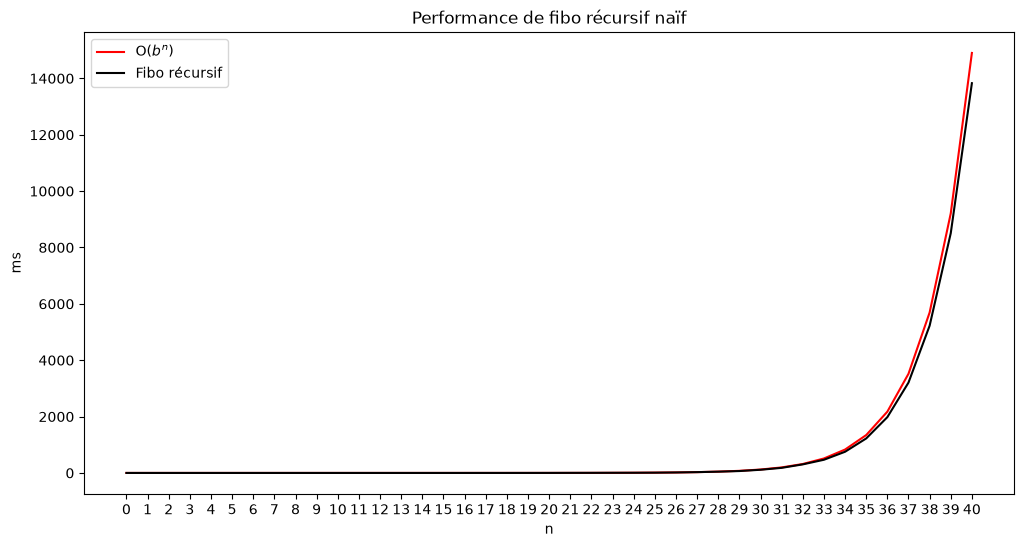

In [7]:
#@title Exercice 4.5
import matplotlib.pyplot as plt
import timeit
import numpy as np

BASE = 1.618    #  (1+sqrt(5))/2)  qui est fibo(n+1)/fibo(n) si n est grand
FACTEUR_MUL = 1000  # On multiplie par 1000 pour avoir le temps en ms

def fibo_recursif_naif(n):
    if n <= 1:
        return n
    else:
        return fibo_recursif_naif(n-2) + fibo_recursif_naif(n - 1)

temps_base = timeit.timeit(lambda: fibo_recursif_naif(0), number=1_000_000) / 1_000_000

valeurs_n = list(range(41))
y_bn = [0]      # Pour que le premier point soit 0,0
y_fibo = [0]

for i in range(1, len(valeurs_n)):
    n = valeurs_n[i]
    y_bn.append(temps_base * BASE**n  * FACTEUR_MUL)
    temps_fibo = timeit.timeit(lambda: fibo_recursif_naif(n), number=1)
    y_fibo.append(temps_fibo  * FACTEUR_MUL)

plt.figure(figsize=(12, 6))

plt.title("Performance de fibo récursif naïf")
plt.xlabel("n")
plt.ylabel("ms")

plt.xticks(ticks=valeurs_n)
plt.plot(valeurs_n, y_bn, "-r", label=f"O($b^n$)")
plt.plot(valeurs_n, y_fibo, "-k", label=f"Fibo récursif")

plt.legend()
plt.show()


In [ ]:
#@title Exercice 4.6

def sous_ensemble_somme(elements, n, somme):
    if somme == 0:
        return True
    if n == 0:
        return False
    if elements[n-1] > somme:
        return sous_ensemble_somme(elements, n-1, somme)
    else:
        return sous_ensemble_somme(elements, n-1, somme - elements[n-1]) or sous_ensemble_somme(elements, n-1, somme)


def sous_ensemble_somme_dynamique(elements, n, somme, matrice):
    if somme == 0:
        return True
    if n == 0:
        return False
    if elements[n-1] > somme:
        return sous_ensemble_somme_dynamique(elements, n-1, somme, matrice)
    else:
        # C'est ici que ça change. Si on peut déjà soustraire un résultat calculé, on le fait
        if matrice[somme][n-1] is not None:
            return matrice[somme][n-1]
        else:
            cote_gauche = sous_ensemble_somme_dynamique(elements, n-1, somme - elements[n-1], matrice)
            cote_droit = sous_ensemble_somme_dynamique(elements, n-1, somme, matrice)
            matrice[somme - elements[n-1]][n-1] = cote_gauche
            matrice[somme][n-1] = cote_droit
            return cote_gauche or cote_droit



liste = [4, 8, 12, 16, 10]

somme = 18
ligne = [None] * len(liste)
matrice = [ligne] * (somme+1)
print(sous_ensemble_somme_dynamique(liste, len(liste), somme, matrice))

somme = 21
ligne = [None] * len(liste)
matrice = [ligne] * (somme+1)
print(sous_ensemble_somme_dynamique(liste, len(liste), somme, matrice))


# print(sous_ensemble_somme(liste, len(liste), 18))
# print(sous_ensemble_somme(liste, len(liste), 21))

True
False
